In [ ]:
#🧠 WHAT IS COHORT?

#👉 Group customers by first purchase month
#👉 Track their activity over time

In [2]:
# STEP 1 — LOAD DATA (transaction-level, not summary)
import pandas as pd
import sqlite3

conn = sqlite3.connect("retailiq.db")

df = pd.read_sql("SELECT CustomerID, InvoiceDate FROM retail_data", conn)

df.head()


,CustomerID,InvoiceDate
0,17850,2010-12-01 08:26:00
1,17850,2010-12-01 08:26:00
2,17850,2010-12-01 08:26:00
3,17850,2010-12-01 08:26:00
4,17850,2010-12-01 08:26:00


In [4]:
# STEP 2 — PREPARE DATA
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Extract Year-Month
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')

# First purchase (Cohort)
df['CohortMonth'] = df.groupby('CustomerID')['InvoiceMonth'].transform('min')


In [5]:
# STEP 3 — COHORT INDEX (Time Difference)
def get_month_diff(d1, d2):
    return (d1.year - d2.year) * 12 + (d1.month - d2.month)

df['CohortIndex'] = df.apply(
    lambda row: get_month_diff(row['InvoiceMonth'], row['CohortMonth']),
    axis=1
)


In [6]:
# STEP 4 — BUILD COHORT TABLE
cohort_data = df.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'] \
                .nunique() \
                .reset_index()

cohort_pivot = cohort_data.pivot(
    index='CohortMonth',
    columns='CohortIndex',
    values='CustomerID'
)


In [7]:
# STEP 5 — RETENTION MATRIX
cohort_size = cohort_pivot.iloc[:, 0]

retention = cohort_pivot.divide(cohort_size, axis=0)

retention.round(3)


CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
2010-12,1.0,0.366,0.323,0.384,0.363,0.398,0.363,0.349,0.354,0.395,0.374,0.503,0.266
2011-01,1.0,0.221,0.266,0.230,0.321,0.288,0.247,0.242,0.300,0.326,0.365,0.118,NaN
2011-02,1.0,0.187,0.187,0.284,0.271,0.247,0.253,0.279,0.247,0.305,0.068,NaN,NaN
2011-03,1.0,0.150,0.252,0.199,0.223,0.168,0.268,0.230,0.279,0.086,NaN,NaN,NaN
2011-04,1.0,0.213,0.203,0.210,0.197,0.227,0.217,0.260,0.073,NaN,NaN,NaN,NaN
2011-05,1.0,0.190,0.173,0.173,0.208,0.232,0.264,0.095,NaN,NaN,NaN,NaN,NaN
2011-06,1.0,0.174,0.157,0.264,0.231,0.335,0.095,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,1.0,0.181,0.207,0.223,0.271,0.112,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,1.0,0.207,0.249,0.243,0.124,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


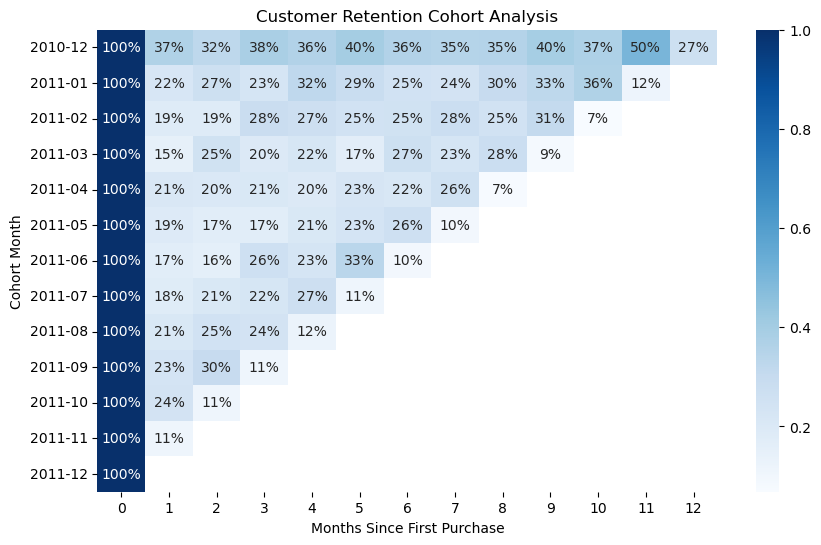

In [8]:
# STEP 6 — VISUALIZATION 
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(
    retention,
    annot=True,
    fmt=".0%",
    cmap="Blues"
)

plt.title("Customer Retention Cohort Analysis")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")

plt.show()


In [10]:
#Find best cohort:
retention.mean(axis=1).sort_values(ascending=False)

CohortMonth
2011-12    1.000000
2011-11    0.555728
2011-10    0.451583
2010-12    0.418253
2011-09    0.412207
2011-08    0.364497
2011-07    0.332447
2011-01    0.326938
2011-06    0.322314
2011-02    0.302632
2011-05    0.291813
2011-04    0.288889
2011-03    0.285619
Freq: M, dtype: float64